### **Introduction**
This data analysis utilizes a dataset containing life expectancy and GDP data for five countries over multiple years. By examining both temporal and cross-country variations, the study seeks to uncover patterns that illustrate how improvements in economic growth may correspond to changes in population health outcomes.

#### **Project Scope**

- Investigates the relationship between life expectancy and economic performance (GDP) across five countries over multiple years.  
- Analyzes data patterns to understand how economic growth influences population health outcomes.  
- Summarizes and visualizes key statistics using tables**, line plots, bar charts, and box plots to highlight variations and trends across time and countries.  
- Explores relationships between GDP and life expectancy through scatter plots, trend analysis, and correlation measures.  
- Applies statistical methods to evaluate the significance and strength of observed relationships between economic and health indicators.  
- Builds predictive models (e.g., regression) to estimate life expectancy based on GDP and time, assessing accuracy and reliability.  
- Combines data visualization, statistical analysis, and predictive modeling to deliver insights on the socioeconomic factors shaping global health and longevity.  


#### Data Overview
The dataset consists of 96 observations and four key attributes representing annual life expectancy and GDP data for six countries. It combines both cross-sectional and time-series characteristics, enabling comparative and trend-based analyses. The dataset comprises one categorical variable and three numeric variables:

- Categorical variable: Country
- Numeric variable: Year, Life expectancy at birth (years), GDP

The categorical data, Country consist of:

1. Chile
2. China
3. Germany
4. Mexico
5. United States of America
6. Zimbabwe


Loading the CSV dataset and checking the data types containing life expectancy, years and GDP.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import plotly.express as px
from pathlib import Path
import seaborn as sns

life_data = pd.read_csv('all_data.csv')
life_data.info()
life_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


Data cleaning:
- Rename 'Life expectancy at birth (years)' to 'Life_expectancy_years'
- Update the country name from 'United States of America' to 'USA'.
- Convert GDP by dividing the column value by 1e9
- A new column 'GDP_in_billion' is created to handle large values of GDP

In [134]:
life_data.rename(columns={'Life expectancy at birth (years)': 'Life_expectancy_years'}, inplace=True)
life_data['Country'] = life_data['Country'].replace({'United States of America': 'USA'})
life_data['GDP_in_trillion'] = life_data['GDP'] / 1e12
# life_data.drop(columns=['GDP'], inplace=True)


#### Summary statistics
This stage focuses on identifying central tendencies, dispersion, and overall trends to build an initial understanding of the data before deeper exploration and modeling.
These statistics provide insight into the range and variability of life expectancy and GDP across all observations. 
- The mean and standard deviation help establish the central tendency and spread of each variable, 
- Minimum and Maximum values indicate the observed extremes across the dataset.
- Average of Life expectancy and GDP across the five selected countries


Summary statistics of GDP and Life expectancy:

In [ ]:
life_data.describe()[['Life_expectancy_years', 'GDP_in_trillion']]

Calculating frequency per Country:

In [135]:
life_data['Country'].value_counts()

Country
Chile       16
China       16
Germany     16
Mexico      16
USA         16
Zimbabwe    16
Name: count, dtype: int64

##### Compare GDP Vs Life Expectancy groupings
The 'groupby' function highlights the average life expectancy and GDP for each country, offering a quick comparison of relative economic performance and health outcomes.
- Germany has the highest average life expectancy with Zimbabwe recording the lowest average over time.
- USA has the highest average GDP of 14.8 trillion dollars over time with Zimbabwe having the lowest 0.01 trillion dollars.

In [83]:
life_data.groupby('Country')[['Life_expectancy_years', 'GDP_in_trillion']].mean().round(2)

,Life_expectancy_years,GDP_in_trillion
Country,,
Chile,78.94,0.17
China,74.26,4.96
Germany,79.66,3.09
Mexico,75.72,0.98
USA,78.06,14.08
Zimbabwe,50.09,0.01


Mininum and Maximum of GDP and Life expectancy per country between 2000 and 2015

In [ ]:
print("==== Life Expectancy per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", (int(country_data['Life_expectancy_years'].min()), int(country_data['Life_expectancy_years'].max())))

print("==== GDP per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", (float(round(country_data['GDP_in_trillion'].min(), 4)), float(round(country_data['GDP_in_trillion'].max(), 4))))       

The data visualization in Fig. 1 illustrates the distribution of life expectancy across countries, highlighting both the median and the variability.
Meanwhile, the boxplot in Fig. 2 uses a logarithmic scale to compare GDP levels across countries with different economic sizes more effectively. This approach helps to explore whether higher GDPs are associated with higher or more stable life expectancy values.

Results:
- Countries like Chile, China, Germany, and the USA show narrow boxes, indicating low variation in life expectancy over time. This suggests that life expectancy remained relatively stable in these countries, with overall high values.
- Conversely, a wider box for Zimbabwe indicates greater fluctuations in life expectancy, reflecting improvements over time. Although Zimbabwe's life expectancy remains the lowest among the countries analyzed, ranging between 44 and 60 years, it recorded improvement which could be clearly seen through the time series plot 'lineplot'.
- Germany, Mexico, and the USA exhibit very low variation in GDP over the years, with no extreme spikes among higher-income observations.
- China shows a steady increase in GDP, with moderate variation over time.
- Zimbabwe has the lowest GDP, with a small difference between the median and the 25th percentile.
- Overall, countries with relatively high GDPs, such as the USA, Germany, Mexico, and China, tend to have correspondingly higher life expectancy.



Side by side boxplot (Life expectancy Vs GDP)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(data=life_data, x='Country', y='Life_expectancy_years', palette='Set2', showmeans=True)
plt.title('Figure 1: Distribution of Life Expectancy by Country')
plt.xlabel('Country')
plt.ylabel('Life Expectancy (years)')

plt.subplot(1,2,2)
sns.boxplot(data=life_data, x='Country', y='GDP', palette='Set3')
plt.title('Figure 2: Distribution of GDP by Country')
plt.xlabel('Country')
plt.ylabel('GDP (USD)')
plt.yscale('log')  # Log scale for better visualization

plt.show()

Check the year interval

In [86]:
print(sorted(life_data.Year.unique().tolist()) )

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]


##### Time Series (GDP vs Life Expectancy)

The next visualization examines how life expectancy and GDP evolved from 2000 to 2015. The line plot highlights the trends and provides deeper insight into how both indicators changed over time.

Results:
- There was a steady drop in life expectancy for Zimbabwe between 2000 and 2004 but observed upward trajectory between 2004 and 2015
- Other countries like USA, China, Chile, Mexico and Germany observed slight rise and drop in both Life expectancy and GDP
- Zimbabwe observed a drop in GDP between 2000 and 2008 and picked up between 2008 and 2015

Side by side Lineplot:

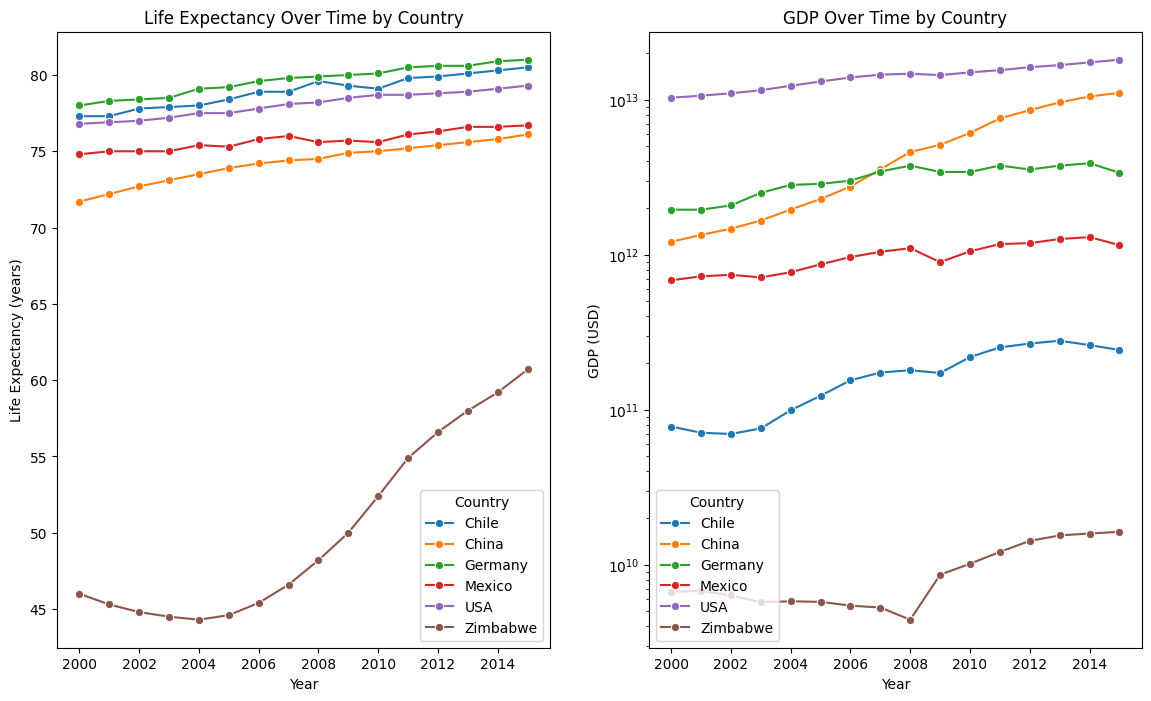

In [87]:
plt.figure(figsize=(14,8))
ax1 = plt.subplot(1,2,1)
sns.lineplot(data=life_data, x='Year', y='Life_expectancy_years', hue='Country', marker='o')
plt.title('Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')

plt.subplot(1,2,2)
sns.lineplot(data=life_data, x='Year', y='GDP', hue='Country', marker='o')
plt.title('GDP Over Time by Country')
plt.xlabel('Year')
plt.ylabel('GDP (USD)')
plt.yscale('log')
plt.legend(title='Country')

plt.show()




##### Average per country trends

The data is organized with countries as the index and years as the columns, while GDP and life expectancy serve as the summarized values by using a pivot table. The objective is to:

- Get the average of GDP and Life expectancy per country, line them up in a Lineplot and observe the trends.
- Compare the data of the country-level plot with and without the average of GDP and Life expectancy.
- A Lineplot is used to visualize the trends between GDP and Life Expectancy over the period of 15 years.

Pivotting the dataset:

In [ ]:
df_pivot = life_data.pivot_table(
    index='Country', 
    columns='Year', 
    values=['GDP', 'Life_expectancy_years'], 
    aggfunc='mean'
)
df_pivot.head()

Next step is to apply the stack function to move the 'Year' column level into the row index, transforming the dataset wide-format into a long-format data structure. Specifically, we will:

- Stack the data at level 1 (the second-level column index corresponding to 'Year') to pivot it into the row index
- Rename the resulting columns (GDP and Life_expectancy) to indicate that they represent average values
- Reset the index to finalize the long-format structure

Stacking the dataset:


In [ ]:
df_pivot = df_pivot.stack(level=1).rename(
    columns={'GDP': 'Avg_GDP', 'Life_expectancy_years': 'Avg_Life_expectancy'}
).reset_index()

df_pivot.head()

##### Summary of Key Descriptive Insights
- The time-series line plot of the average GDPs per country appears to diverge from the original country-level plots in several places, indicating that there may be anomalies or outliers affecting the averaged values. However, this discrepancy in the data needs to be proved.
- The line plot of the average life expectancy closely follows the individual country-level trends, suggesting that there are no noticeable anomalies in the life expectancy data.

Note: The deviations will be studied in the Exploration Data Analysis section of this project.

Plotting average GDP & Life expectancy per year (Time Series):

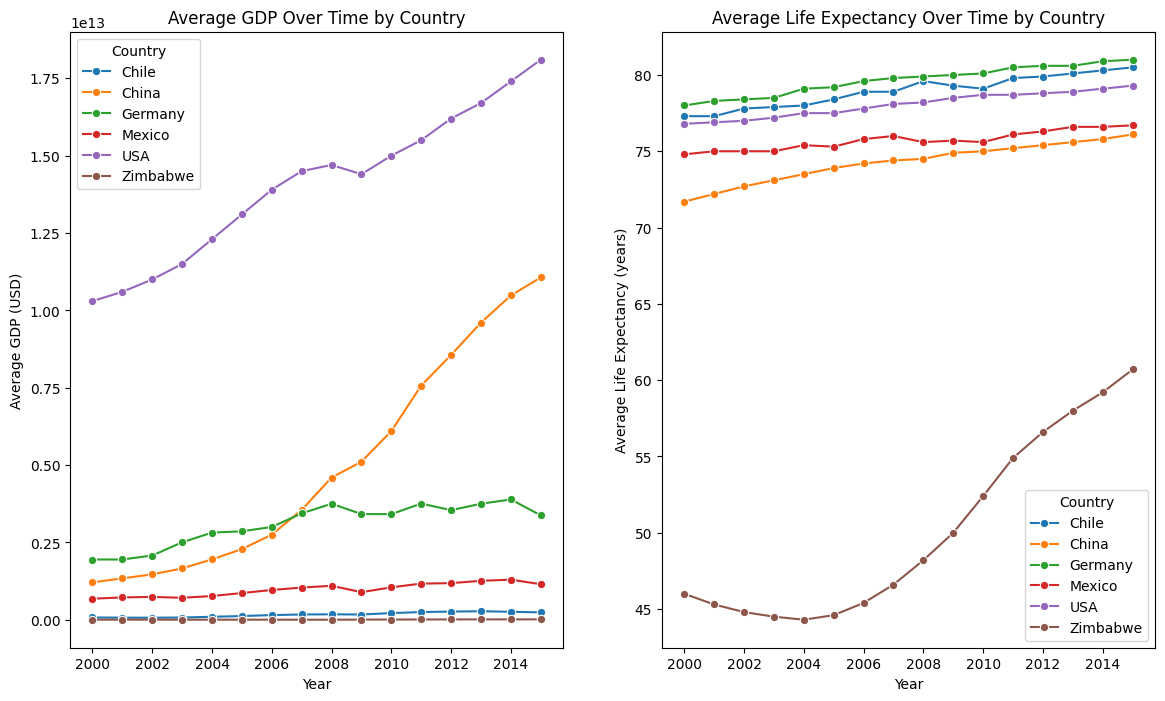

In [93]:
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.lineplot(data=df_pivot, x='Year', y='Avg_GDP', hue='Country', marker='o')
plt.title('Average GDP Over Time by Country')
plt.xscale
plt.xlabel('Year')
plt.ylabel('Average GDP (USD)')
plt.legend(title='Country') 

plt.subplot(1,2,2)
sns.lineplot(data=df_pivot, x='Year', y='Avg_Life_expectancy', hue='Country', marker='o')
plt.title('Average Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

#### Exploratory Data Analysis (EDA)
Exploratory Data Analysis aims to uncover underlying patterns, relationships, and anomalies within the dataset. In this stage, we go beyond summary statistics to visually and quantitatively examine how economic performance (GDP) and life expectancy interact across different countries and time periods.

The objectives of this analysis are to:
- Explore the relationship between life expectancy and GDP.
- Identify correlation strength and direction between the two variables.
- Detect potential outliers or deviations from general trends.
- Visualize cross-country and temporal variations.

Interpretation:

A positive correlation suggests that as GDP increases, life expectancy also tends to rise. The strength of this correlation indicates how closely linked economic prosperity and life expectancy outcomes are across the observed countries and years. Earlier, we calculated an overall correlation of 0.343 across all countries, which is weaker than the correlations observed at the individual country level.

Results:
- The correlation value of individual country shows a very strong positive correlation indicating linearity
- The scatter plot displayed below illustrates how life expectancy changes with increasing GDP


Correlation Between GDP and Life Expectancy:

In [ ]:
# Compute the Pearson correlation coefficient
corr_value = life_data['Life_expectancy_years'].corr(life_data['GDP'])
print(f"Correlation between GDP and Life Expectancy: {corr_value:.3f}")

##### Relationship between GDP and Life expectancy per Country
This analysis illustrates the correlation/relationship between GDP and life expectancy for each country compared to the overall correlation across all countries.

Interpretation:

- In the table below, obtained from groupby function shows how the relationship between GDP and life expectancy varies across countries. A stronger correlation for certain countries might reflect consistent socioeconomic improvements, whereas weaker correlations may indicate additional factors influencing life expectancy like the GDP of a country.
- This scatter plot illustrates how life expectancy changes with increasing GDP. 

Results of the analysis below:
- The observed correlation values indicate that there is a strong positive correlation between each country's GDP and Life expectancy.
- USA has the highest correlation value of 0.982 while Mexico has the lowest with the value of 0.932
- In the scatter plot, countries clustering along an upward trajectory indicate a strong positive association.
- Zimbabwe’s GDP shows a slight initial decline over the period, followed by a sharp recovery, although overall changes remain relatively small.

In [ ]:
country_corr = life_data.groupby('Country')[['GDP', 'Life_expectancy_years']].corr().unstack().iloc[:,1].round(3)
country_corr

Scatter Plot (GDP vs. Life Expectancy) per country : 

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=life_data, x='GDP', y='Life_expectancy_years', hue='Country', palette='Dark2', s=70)
plt.xscale('log')  # Log scale for GDP to manage large range differences
plt.title('Relationship Between GDP and Life Expectancy')
plt.xlabel('GDP (log scale, USD)')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

#### Outlier detection
Firstly, we check if there are outliers in GDP and Life expectancy per country in the dataset. Previous data analysis of the average GDP and Life expectancy suggested that there might be the presence of outliers clearly shown in the lineplot.
Here, we do the following to check the presence of outliers:

- Check the lower and upper bound of the GDP and Life expectancy per country
- Filter the dataset for the lower and upper bound
- Validate the dataset if there was outlier or not in GDP and life expectancy per country


The analysis indicates that no outliers were detected in the GDP or life expectancy data for any country. The minor deviations observed in the earlier line plot are likely attributable to small gaps in the recorded GDP and life expectancy values. These gaps may account for the observed differences between the datasets with and without averaging.

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    # If no outliers, set explicitly to "No Outliers"
    if outliers.empty:
        outliers_result = "No Outliers"
    else:
        outliers_result = outliers

    return outliers_result, lower, upper

# Dictionary to store results
outlier_results = {}

# Loop per country
for country, group in life_data.groupby("Country"):

    country_stats = {}

    for col in ['GDP', 'Life_expectancy_years']:
        outliers, lower, upper = detect_outliers_iqr(group, col)

        country_stats[col] = {
            "Number of Outliers": 0 if outliers == "No Outliers" else len(outliers),
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2),
            "Outlier Rows": outliers
        }

    outlier_results[country] = country_stats

# Convert to a readable summary DataFrame
summary_rows = []
for country, stats in outlier_results.items():
    for col, result in stats.items():
        summary_rows.append({
            "Country": country,
            "Column": col,
            "Number of Outliers": result["Number of Outliers"],
            "Lower Bound": result["Lower Bound"],
            "Upper Bound": result["Upper Bound"]
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

##### Distribution of GDP and Life expectancy
It is important to observe the distribution of the data in relation to each country's GDP and Life expectancy. 

Interpretation of results:

- The histograms for GDP and life expectancy across the six countries display clear skewness and gaps between bars. These patterns are expected because each country has a relatively small number of yearly observations, and the variables themselves do not change continuously over time. 
- GDP typically grows in irregular steps, producing a right-skewed distribution, while life expectancy rises slowly across years, creating clustered and uneven bar patterns. 
- The empty spaces in the histograms occur when no data points fall within certain ranges, which is normal for socioeconomic time-series data with small sample sizes.

In [ ]:
columns_to_plot = ['GDP', 'Life_expectancy_years']

# Set seaborn style
sns.set(style="whitegrid")
n = 1
# Loop through each country
plt.figure(figsize=(14, 8))
for country, group in life_data.groupby("Country"):

    # Plot histograms for each variable
    for col in columns_to_plot:
        plt.subplot(3, 4, n)
        n += 1
        sns.histplot(
            data=group,
            x=col,
            kde=True,
            bins=20,
            edgecolor='black'
        )

        plt.title(f"{col.replace("_"," ")} Distribution for {country}", fontsize=12)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Frequency", fontsize=12)
        plt.tight_layout()
plt.show()       

### Understanding the Distribution of GDP and Life Expectancy
Since histograms can look jagged for small datasets, a Kernel Density Estimation (KDE) can be to visualize smoother distributions for each country.
The histogram and KDE visualizations reveal how GDP and life expectancy are distributed across time for each country. The following have been observed and explained:
- GDP shows a clear right-skewed pattern, which is typical of economic time series where income rises unevenly year after year. 
- The presence of gaps in the histogram bars reflects the fact that the data does not cover every possible GDP value, especially when growth occurs in larger jumps. 
- Because each country has a limited number of annual observations, these gaps and irregularities are expected.

- Life expectancy exhibits a different distributional pattern. The values tend to cluster tightly within a relatively narrow range and change gradually over time. 
- This produces histograms with uneven bar spacing but KDE curves with smooth, narrow peaks. 
- These patterns suggest consistent improvement in health outcomes, with minimal volatility across years.


Overall, the combination of histograms and KDE plots provides insight into the shape, spread, and skewness of each country’s economic and health indicators, helping to highlight differences in development trajectories and stability. A KDE plot was used to smooth the data distribution, enabling clearer interpretation of the underlying patterns. 


Interpretation of KDE distribution:

- Kernel Density Estimation (KDE) produces smooth curves that represent the probability distribution of the data. 
- KDE works by placing small bell-shaped curves (kernels) on each data point and adding them together, allowing us to see the underlying distribution without the jagged appearance of histograms. 
- The KDE plots reveal multiple peaks in the GDP and life expectancy distributions for several countries, including the USA, Chile, China, Mexico, and Zimbabwe. These multiple peaks indicate the presence of more than one cluster within the data. For example, in Chile, Mexico, and Zimbabwe, earlier years with lower GDP or life expectancy form one peak, while later years with higher values form another. 
- This pattern reflects distinct economic or health phases over time, allowing us to identify shifts in development or well-being within each country.



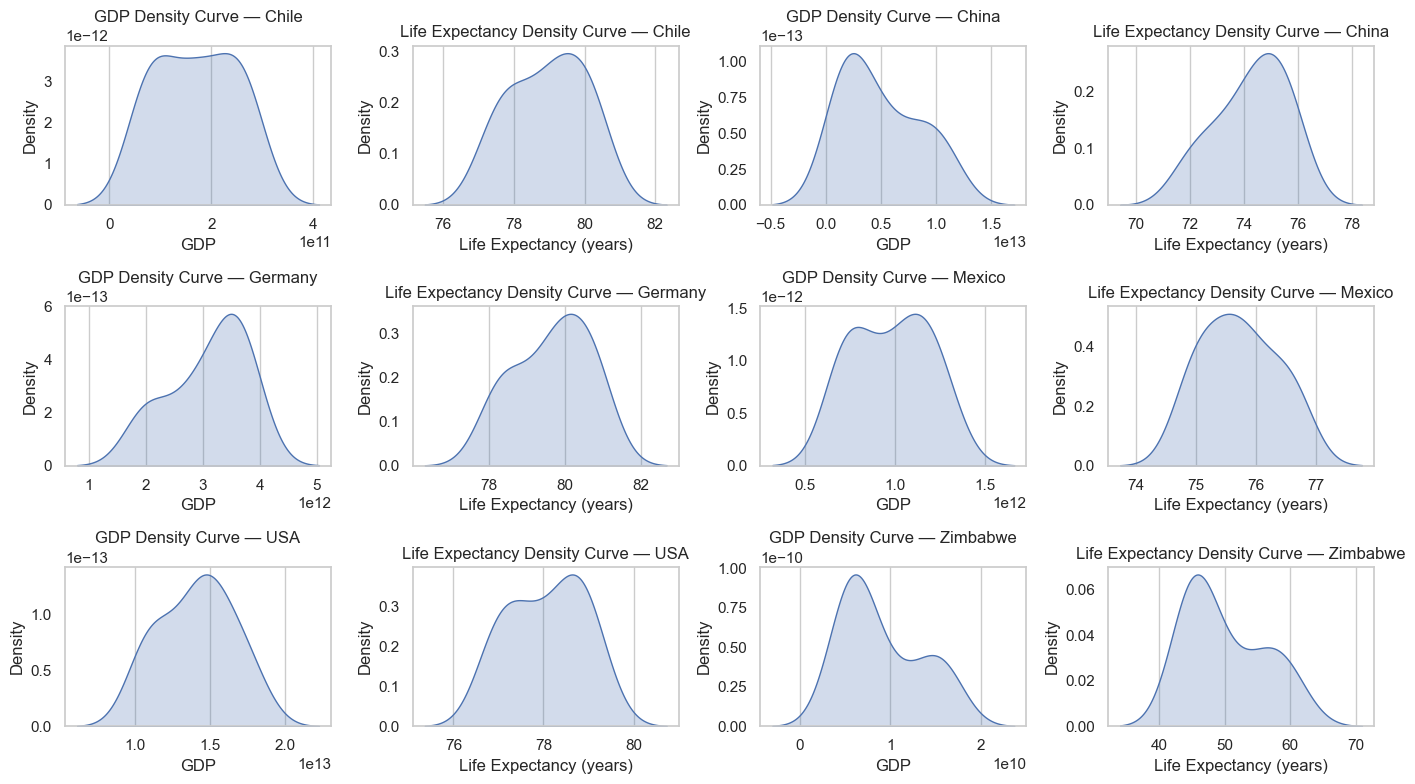

In [153]:
countries = life_data["Country"].unique()
indexNow = 1
# KDE for GDP and Life Expectancy per Country
plt.figure(figsize=(14,8))
for country in countries:
    subset = life_data[life_data["Country"] == country]

    # GDP KDE
    plt.subplot(3, 4, indexNow)
    indexNow += 1  
    sns.kdeplot(subset["GDP"], fill=True)
    plt.title(f"GDP Density Curve — {country}")
    plt.xlabel("GDP")
    plt.ylabel("Density")
    plt.grid(axis="y")


    # Life Expectancy KDE
    plt.subplot(3, 4, indexNow)
    sns.kdeplot(subset["Life_expectancy_years"], fill=True)
    plt.title(f"Life Expectancy Density Curve — {country}")
    plt.xlabel("Life Expectancy (years)")
    plt.ylabel("Density")
    plt.grid(axis="y")
    indexNow += 1
    
plt.tight_layout()
plt.show()